# Customer Churn Prediction with AutoML

**Objective**: Train a machine learning model to predict customer churn risk using Databricks AutoML.

**Current State**: Rule-based scoring system using RFM (Recency, Frequency, Monetary) metrics with manual thresholds.

**Goal**: Train a production ML model to replace rule-based scoring and deploy predictions to the Gold churn-score table (`workspace.retail.gold_customer_churn_scores`) that gets synced to Lakebase and served by the RetailIQ Insights app.

**Data**: `workspace.retail.gold_customer_churn_features` - 5,000 customers with ML-ready features
- Target: `churn_label_proxy` (1 = high risk, 0 = low risk)
- Distribution: ~29% high-risk, ~71% low-risk (imbalanced)

**AutoML Config**:
- Binary classification
- Primary metric: F1 score
- Timeout: 15 minutes
- Max trials: 10 models

In [0]:
%pip install databricks-automl-runtime xgboost seaborn --quiet
dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

# Load training data
df = spark.table("workspace.retail.gold_customer_churn_features").toPandas()

# Basic dataset info
print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic statistics:")
display(df.describe())

Dataset shape: (5000, 14)

Features: ['customer_id', 'loyalty_tier', 'points_balance', 'customer_tenure_days', 'days_since_last_purchase', 'transactions_last_30d', 'transactions_last_90d', 'revenue_last_30d', 'revenue_last_90d', 'avg_order_value', 'preferred_channel', 'refund_return_rate', 'favorite_category', 'churn_label_proxy']

Data types:
customer_id                  object
loyalty_tier                 object
points_balance              float64
customer_tenure_days          int32
days_since_last_purchase      int32
transactions_last_30d         int64
transactions_last_90d         int64
revenue_last_30d            float64
revenue_last_90d            float64
avg_order_value             float64
preferred_channel            object
refund_return_rate          float64
favorite_category            object
churn_label_proxy             int32
dtype: object

Missing values:
customer_id                    0
loyalty_tier                1500
points_balance              1500
customer_tenure_days

points_balance,customer_tenure_days,days_since_last_purchase,transactions_last_30d,transactions_last_90d,revenue_last_30d,revenue_last_90d,avg_order_value,refund_return_rate,churn_label_proxy
3500.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
13370.968285714285,542.4796,101.1818,0.9474,2.3874,253.37063200000003,631.0730480000001,199.0178089640999,0.029267674775318313,0.343
24309.288147606243,316.6957120307184,476.5045683616201,1.502093371564957,3.229459261459151,481.3529408821969,996.6714037917498,82.10515267200249,0.07261724045913012,0.47475896960019953
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2143.0,270.0,11.0,0.0,0.0,0.0,0.0,140.04666666666665,0.0,0.0
4427.0,537.0,39.0,0.0,1.0,0.0,189.125,187.655,0.0,0.0
12238.25,817.0,107.0,1.0,3.0,268.5475,703.8425000000001,249.67851190476193,0.0,1.0
148188.0,1095.0,9999.0,9.0,18.0,3851.1800000000003,7250.889999999999,1118.36,1.0,1.0


Churn Label Distribution:
Low Risk (0): 3285 customers (65.7%)
High Risk (1): 1715 customers (34.3%)

Class Imbalance Ratio: 1.92:1


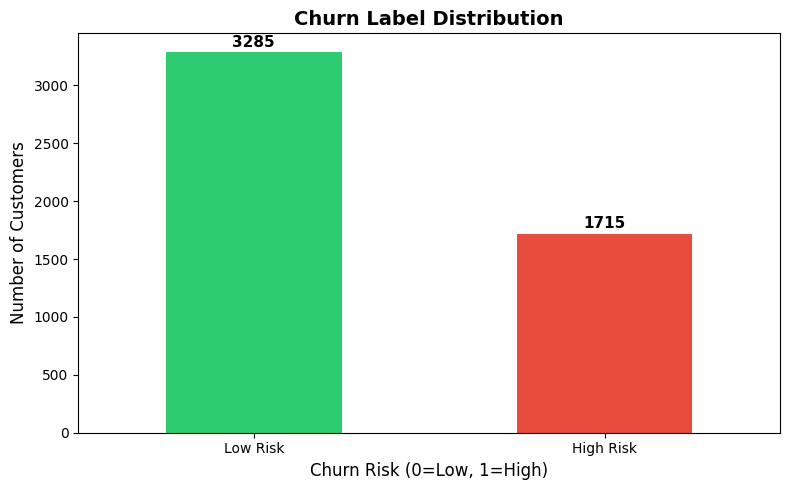

In [0]:
# Analyze target variable distribution
churn_counts = df['churn_label_proxy'].value_counts()
churn_pct = df['churn_label_proxy'].value_counts(normalize=True) * 100

print("Churn Label Distribution:")
print(f"Low Risk (0): {churn_counts[0]} customers ({churn_pct[0]:.1f}%)")
print(f"High Risk (1): {churn_counts[1]} customers ({churn_pct[1]:.1f}%)")
print(f"\nClass Imbalance Ratio: {churn_pct[0]/churn_pct[1]:.2f}:1")

# Visualize class distribution
fig, ax = plt.subplots(figsize=(8, 5))
churn_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn Label Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Risk (0=Low, 1=High)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_xticklabels(['Low Risk', 'High Risk'], rotation=0)
for i, v in enumerate(churn_counts):
    ax.text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

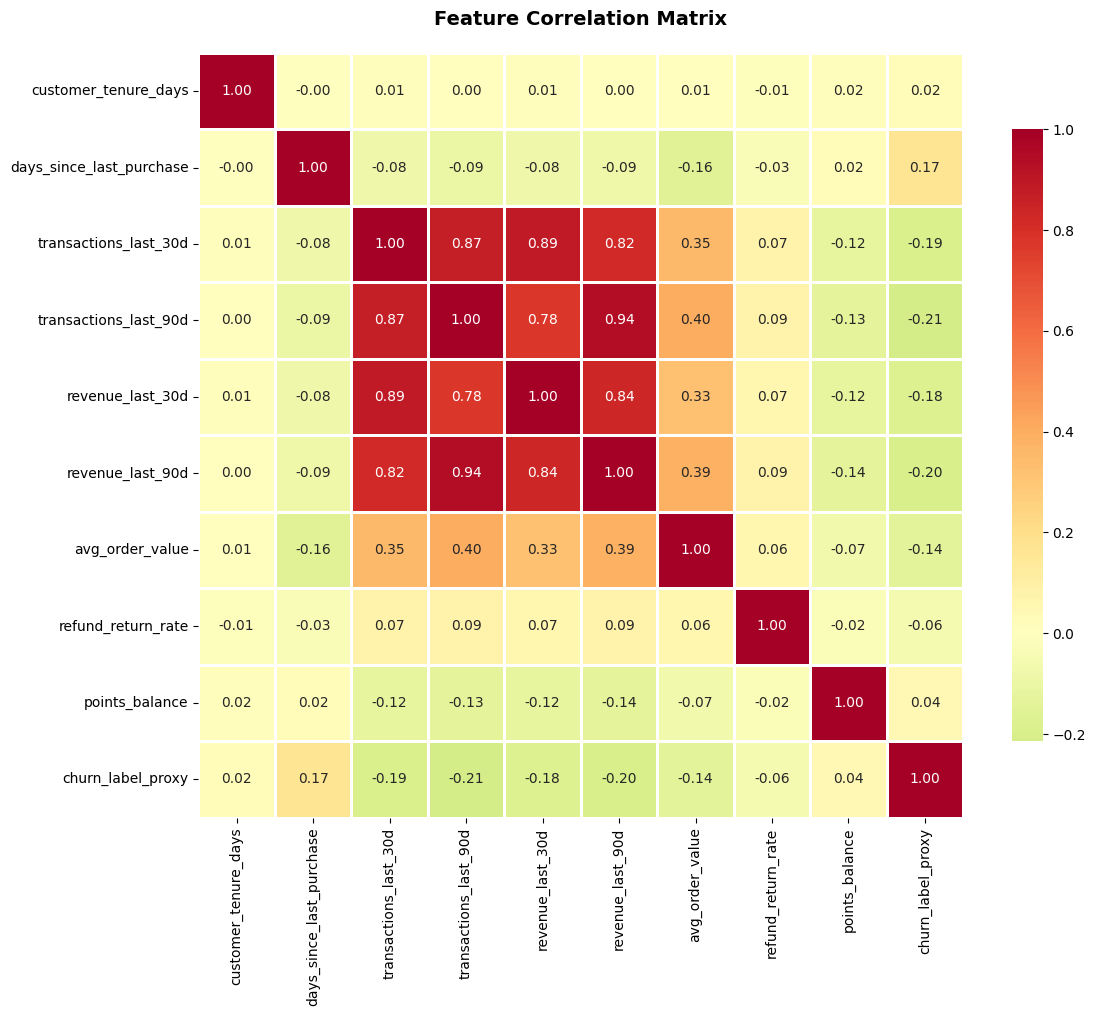


Correlations with Churn Label (sorted by absolute value):
transactions_last_90d       0.214023
revenue_last_90d            0.198104
transactions_last_30d       0.194054
revenue_last_30d            0.175674
days_since_last_purchase    0.168215
avg_order_value             0.142033
refund_return_rate          0.058069
points_balance              0.042181
customer_tenure_days        0.024912
Name: churn_label_proxy, dtype: float64


In [0]:
# Select numerical features for correlation analysis
numerical_features = ['customer_tenure_days', 'days_since_last_purchase', 
                      'transactions_last_30d', 'transactions_last_90d',
                      'revenue_last_30d', 'revenue_last_90d', 'avg_order_value',
                      'refund_return_rate', 'points_balance', 'churn_label_proxy']

# Create correlation matrix
corr_matrix = df[numerical_features].corr()

# Visualize correlations
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show top correlations with target
print("\nCorrelations with Churn Label (sorted by absolute value):")
target_corr = corr_matrix['churn_label_proxy'].drop('churn_label_proxy').abs().sort_values(ascending=False)
print(target_corr)

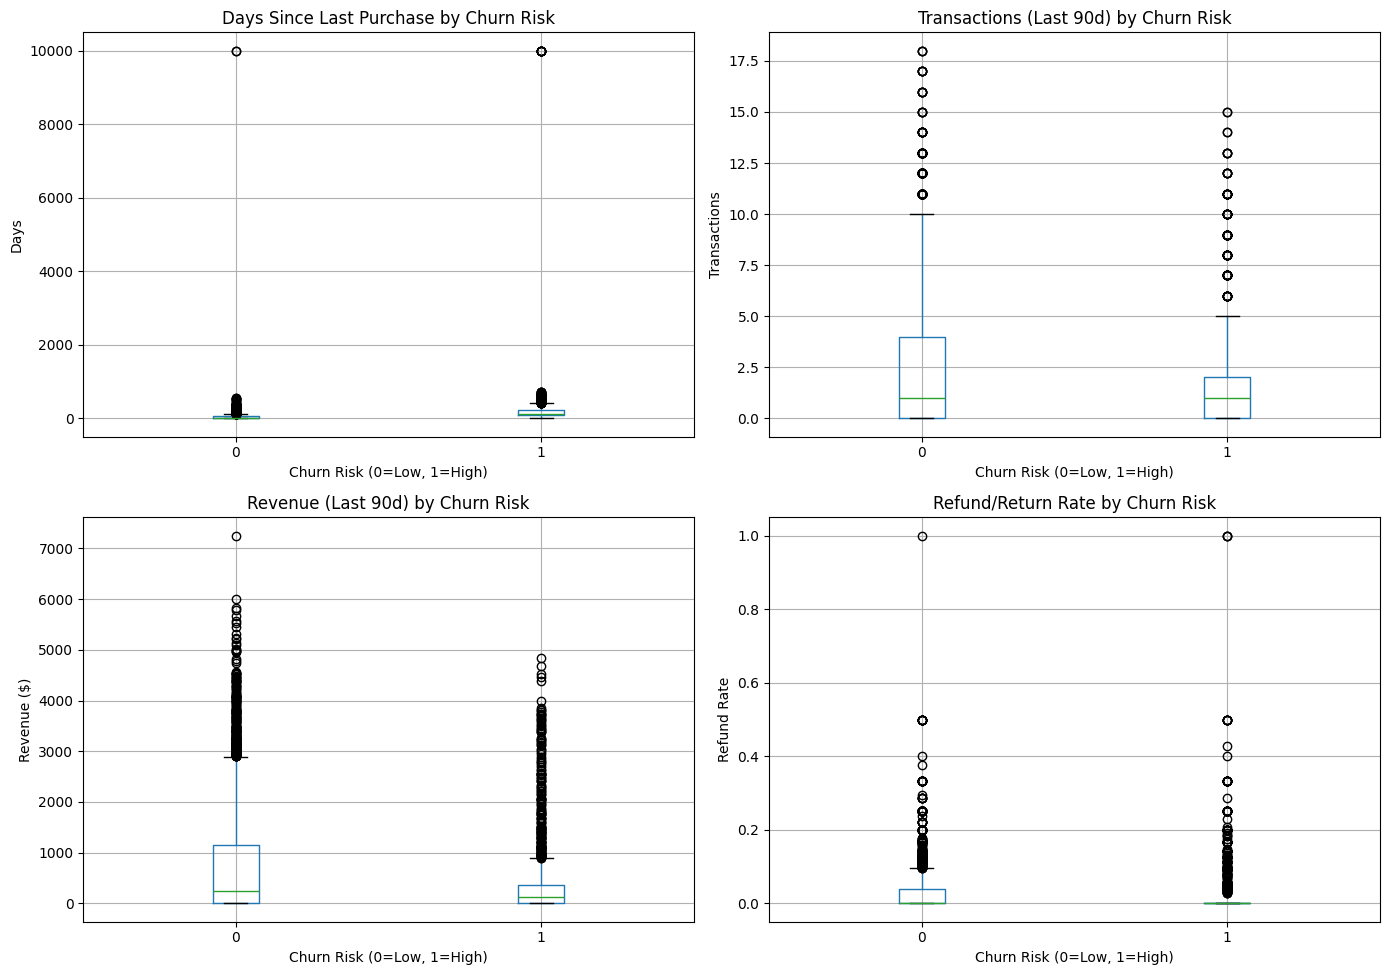

In [0]:
# Visualize key features vs churn label
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Days since last purchase
df.boxplot(column='days_since_last_purchase', by='churn_label_proxy', ax=axes[0,0])
axes[0,0].set_title('Days Since Last Purchase by Churn Risk')
axes[0,0].set_xlabel('Churn Risk (0=Low, 1=High)')
axes[0,0].set_ylabel('Days')

# Transactions last 90 days
df.boxplot(column='transactions_last_90d', by='churn_label_proxy', ax=axes[0,1])
axes[0,1].set_title('Transactions (Last 90d) by Churn Risk')
axes[0,1].set_xlabel('Churn Risk (0=Low, 1=High)')
axes[0,1].set_ylabel('Transactions')

# Revenue last 90 days
df.boxplot(column='revenue_last_90d', by='churn_label_proxy', ax=axes[1,0])
axes[1,0].set_title('Revenue (Last 90d) by Churn Risk')
axes[1,0].set_xlabel('Churn Risk (0=Low, 1=High)')
axes[1,0].set_ylabel('Revenue ($)')

# Refund return rate
df.boxplot(column='refund_return_rate', by='churn_label_proxy', ax=axes[1,1])
axes[1,1].set_title('Refund/Return Rate by Churn Risk')
axes[1,1].set_xlabel('Churn Risk (0=Low, 1=High)')
axes[1,1].set_ylabel('Refund Rate')

plt.suptitle('')
plt.tight_layout()
plt.show()

In [0]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import numpy as np

# Prepare features and target
target_col = 'churn_label_proxy'
exclude_cols = ['customer_id']

y = df[target_col]
X = df.drop(columns=[target_col] + exclude_cols)

# Handle categorical features
categorical_cols = ['loyalty_tier', 'preferred_channel', 'favorite_category']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print(f"Numerical features: {numerical_cols}")
print(f"Categorical features: {categorical_cols}")

# Impute missing values in categorical columns with 'Unknown'
for col in categorical_cols:
    X[col] = X[col].fillna('Unknown')

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"\nFeatures after encoding: {X_encoded.shape[1]} columns")
print(f"Feature names: {X_encoded.columns.tolist()}")

# Split data: 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTrain set: {X_train.shape[0]} samples ({y_train.mean()*100:.1f}% churn)")
print(f"Validation set: {X_val.shape[0]} samples ({y_val.mean()*100:.1f}% churn)")
print(f"Test set: {X_test.shape[0]} samples ({y_test.mean()*100:.1f}% churn)")

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\nData preparation complete!")

Numerical features: ['points_balance', 'customer_tenure_days', 'days_since_last_purchase', 'transactions_last_30d', 'transactions_last_90d', 'revenue_last_30d', 'revenue_last_90d', 'avg_order_value', 'refund_return_rate']
Categorical features: ['loyalty_tier', 'preferred_channel', 'favorite_category']

Features after encoding: 23 columns
Feature names: ['points_balance', 'customer_tenure_days', 'days_since_last_purchase', 'transactions_last_30d', 'transactions_last_90d', 'revenue_last_30d', 'revenue_last_90d', 'avg_order_value', 'refund_return_rate', 'loyalty_tier_Gold', 'loyalty_tier_Platinum', 'loyalty_tier_Silver', 'loyalty_tier_Unknown', 'preferred_channel_In-Store', 'preferred_channel_Unknown', 'favorite_category_Beauty & Personal Care', 'favorite_category_Electronics', 'favorite_category_Food & Beverage', 'favorite_category_Health & Wellness', 'favorite_category_Home & Garden', 'favorite_category_Sports & Outdoors', 'favorite_category_Toys & Games', 'favorite_category_Unknown']



In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.impute import SimpleImputer

# Handle remaining NaN values (e.g., points_balance for non-loyalty members)
imputer = SimpleImputer(strategy='median')
X_train_scaled = pd.DataFrame(imputer.fit_transform(X_train_scaled), columns=X_train_scaled.columns, index=X_train_scaled.index)
X_val_scaled = pd.DataFrame(imputer.transform(X_val_scaled), columns=X_val_scaled.columns, index=X_val_scaled.index)
X_test_scaled = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test_scaled.columns, index=X_test_scaled.index)

# Impute full encoded dataset for later comparison
imputer_full = SimpleImputer(strategy='median')
X_encoded = pd.DataFrame(imputer_full.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)

# Set MLflow experiment
mlflow.set_experiment("/Users/parvjain2503@gmail.com/churn-prediction-experiment")

# Define models to train
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1, scale_pos_weight=2.4)
}

results = []

print("Training 4 models with MLflow tracking...\n")
print("="*70)

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name):
        print(f"\n📊 Training {model_name}...")
        
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Predictions
        y_pred_train = model.predict(X_train_scaled)
        y_pred_val = model.predict(X_val_scaled)
        y_pred_test = model.predict(X_test_scaled)
        
        # Probabilities for ROC-AUC
        y_proba_val = model.predict_proba(X_val_scaled)[:, 1]
        y_proba_test = model.predict_proba(X_test_scaled)[:, 1]
        
        # Calculate metrics
        metrics = {
            'train_f1': f1_score(y_train, y_pred_train),
            'train_accuracy': accuracy_score(y_train, y_pred_train),
            'val_f1': f1_score(y_val, y_pred_val),
            'val_accuracy': accuracy_score(y_val, y_pred_val),
            'val_precision': precision_score(y_val, y_pred_val),
            'val_recall': recall_score(y_val, y_pred_val),
            'val_roc_auc': roc_auc_score(y_val, y_proba_val),
            'test_f1': f1_score(y_test, y_pred_test),
            'test_accuracy': accuracy_score(y_test, y_pred_test),
            'test_precision': precision_score(y_test, y_pred_test),
            'test_recall': recall_score(y_test, y_pred_test),
            'test_roc_auc': roc_auc_score(y_test, y_proba_test)
        }
        
        # Log parameters and metrics
        mlflow.log_params(model.get_params())
        mlflow.log_metrics(metrics)
        
        # Log model
        if 'XGBoost' in model_name:
            mlflow.xgboost.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")
        
        # Store results
        results.append({
            'model': model_name,
            'model_obj': model,
            **metrics
        })
        
        print(f"  ✓ Val F1: {metrics['val_f1']:.4f}, Val Acc: {metrics['val_accuracy']:.4f}")
        print(f"  ✓ Test F1: {metrics['test_f1']:.4f}, Test Acc: {metrics['test_accuracy']:.4f}")

print("\n" + "="*70)
print("Training complete! ✅\n")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_f1', ascending=False)

print("Model Performance Comparison (sorted by Test F1 Score):\n")
display(results_df[['model', 'test_f1', 'test_accuracy', 'test_precision', 'test_recall', 'test_roc_auc']])

Training 4 models with MLflow tracking...


📊 Training Logistic Regression...


2026/10/07 23:13:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-60f13092-ba07.cloud.databricks.com/ml/experiments/1610455880752638/models/m-c4ae6a3ad25a43cba68fe8f03b5261f8?o=7474656192147877
2026/10/07 23:13:09 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.12.0/ml/model/signatures.html for instructions on setting signature on models.


  ✓ Val F1: 0.7644, Val Acc: 0.8413
  ✓ Test F1: 0.7570, Test Acc: 0.8373

📊 Training Random Forest...


2026/10/07 23:13:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-60f13092-ba07.cloud.databricks.com/ml/experiments/1610455880752638/models/m-fd4be360775540fbbf946615cd4e2331?o=7474656192147877
2026/10/07 23:13:15 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.12.0/ml/model/signatures.html for instructions on setting signature on models.


  ✓ Val F1: 0.7958, Val Acc: 0.8693
  ✓ Test F1: 0.7958, Test Acc: 0.8707

📊 Training Gradient Boosting...


2026/10/07 23:13:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-60f13092-ba07.cloud.databricks.com/ml/experiments/1610455880752638/models/m-7ae71edd8abf4cacb6d14fe56ccbb5e3?o=7474656192147877
2026/10/07 23:13:21 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.12.0/ml/model/signatures.html for instructions on setting signature on models.


  ✓ Val F1: 0.7925, Val Acc: 0.8667
  ✓ Test F1: 0.7941, Test Acc: 0.8693

📊 Training XGBoost...


2026/10/07 23:13:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-60f13092-ba07.cloud.databricks.com/ml/experiments/1610455880752638/models/m-af6566dd6a7e459bba0bed7384155cd6?o=7474656192147877
2026/10/07 23:13:28 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.12.0/ml/model/signatures.html for instructions on setting signature on models.


  ✓ Val F1: 0.7844, Val Acc: 0.8600
  ✓ Test F1: 0.7925, Test Acc: 0.8680

Training complete! ✅

Model Performance Comparison (sorted by Test F1 Score):



model,test_f1,test_accuracy,test_precision,test_recall,test_roc_auc
Random Forest,0.7957894736842105,0.8706666666666667,0.8669724770642202,0.7354085603112841,0.8509246178009644
Gradient Boosting,0.7941176470588235,0.8693333333333333,0.863013698630137,0.7354085603112841,0.8356682267701123
XGBoost,0.7924528301886793,0.868,0.8590909090909091,0.7354085603112841,0.8426689607816829
Logistic Regression,0.7569721115537849,0.8373333333333334,0.7755102040816326,0.7392996108949417,0.84280313493974


Best Model: Random Forest
Test F1 Score: 0.7958
Test Accuracy: 0.8707

Top 15 Most Important Features:



feature,importance
days_since_last_purchase,0.6203510295426868
revenue_last_90d,0.0538843071706596
avg_order_value,0.05033151790426125
customer_tenure_days,0.04770501283872236
transactions_last_90d,0.043715714256042267
revenue_last_30d,0.04029606012696101
points_balance,0.03985926673797125
refund_return_rate,0.02848172371703235
transactions_last_30d,0.017228128188359428
preferred_channel_In-Store,0.012268551289836324


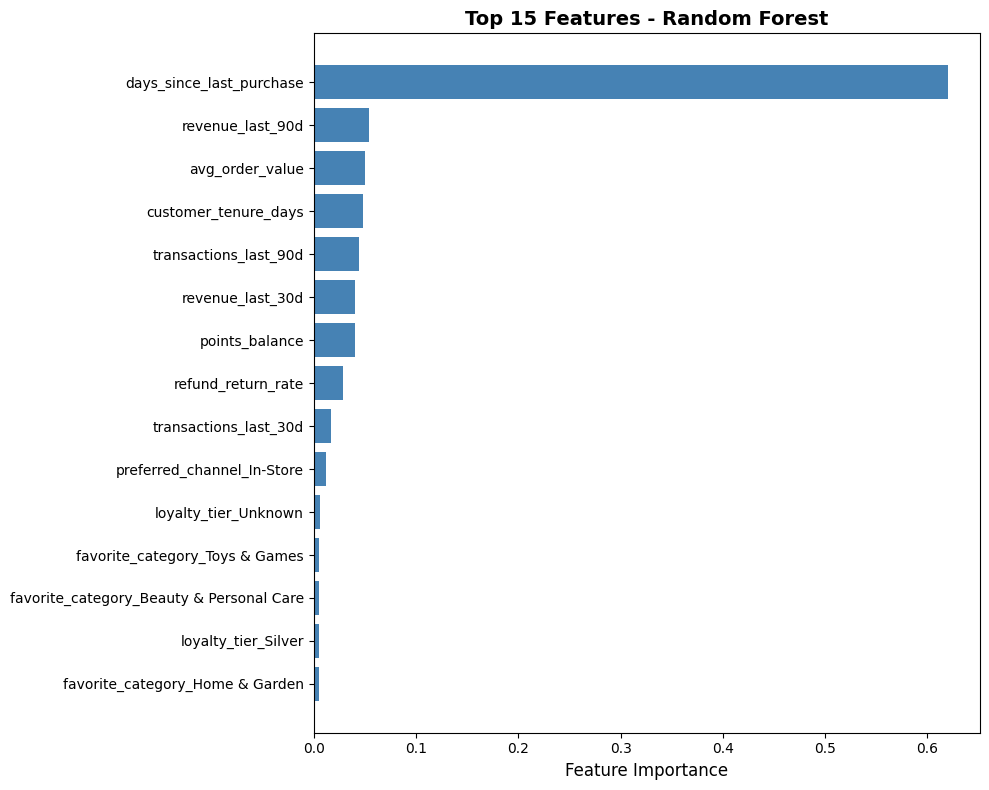


🔍 Key Insights:
  • Most important: days_since_last_purchase
  • Top 3 features: 72.5% of predictive power
  • Top 5 features: 81.6% of predictive power


In [0]:
# Get best model
best_model_name = results_df.iloc[0]['model']
best_model = results_df.iloc[0]['model_obj']

print(f"Best Model: {best_model_name}")
print(f"Test F1 Score: {results_df.iloc[0]['test_f1']:.4f}")
print(f"Test Accuracy: {results_df.iloc[0]['test_accuracy']:.4f}\n")

# Extract feature importance
if hasattr(best_model, 'feature_importances_'):
    # Tree-based models
    feature_names = X_encoded.columns.tolist()
    importance = best_model.feature_importances_
    
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    print("Top 15 Most Important Features:\n")
    display(feature_importance_df.head(15))
    
    # Visualize feature importance
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance_df.head(15)
    ax.barh(top_features['feature'], top_features['importance'], color='steelblue')
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title(f'Top 15 Features - {best_model_name}', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\n🔍 Key Insights:")
    print(f"  • Most important: {feature_importance_df.iloc[0]['feature']}")
    print(f"  • Top 3 features: {feature_importance_df.head(3)['importance'].sum()*100:.1f}% of predictive power")
    print(f"  • Top 5 features: {feature_importance_df.head(5)['importance'].sum()*100:.1f}% of predictive power")
    
elif hasattr(best_model, 'coef_'):
    # Logistic Regression
    feature_names = X_encoded.columns.tolist()
    coefficients = best_model.coef_[0]
    
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefficients,
        'abs_coefficient': np.abs(coefficients)
    }).sort_values('abs_coefficient', ascending=False)
    
    print("Top 15 Most Important Features (by coefficient magnitude):\n")
    display(feature_importance_df.head(15))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = feature_importance_df.head(15)
    colors = ['red' if c < 0 else 'steelblue' for c in top_features['coefficient']]
    ax.barh(top_features['feature'], top_features['coefficient'], color=colors)
    ax.set_xlabel('Coefficient (Negative = Less Churn, Positive = More Churn)', fontsize=12)
    ax.set_title(f'Top 15 Features - {best_model_name}', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

In [0]:
# Load rule-based scores
rule_based_df = spark.table("workspace.retail.gold_customer_churn_scores").toPandas()

# Generate ML predictions for all data
ml_predictions = best_model.predict(X_encoded)
ml_predictions_proba = best_model.predict_proba(X_encoded)[:, 1]

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'customer_id': df['customer_id'],
    'actual_churn': df['churn_label_proxy'],
    'ml_prediction': ml_predictions,
    'ml_churn_probability': ml_predictions_proba
})

# Merge with rule-based scores
comparison_df = comparison_df.merge(rule_based_df[['customer_id', 'churn_score', 'churn_risk_band']], on='customer_id')
comparison_df['rule_based_prediction'] = (comparison_df['churn_risk_band'] == 'High').astype(int)

# Calculate agreement
agreement = (comparison_df['ml_prediction'] == comparison_df['rule_based_prediction']).mean()

print("="*70)
print("ML vs Rule-Based Comparison\n")
print(f"Agreement rate: {agreement*100:.1f}%")
print(f"Disagreements: {len(comparison_df[comparison_df['ml_prediction'] != comparison_df['rule_based_prediction']])} customers\n")

# Analyze disagreements
disagreements = comparison_df[comparison_df['ml_prediction'] != comparison_df['rule_based_prediction']]

ml_says_high = len(disagreements[(disagreements['ml_prediction']==1) & (disagreements['rule_based_prediction']==0)])
ml_says_low = len(disagreements[(disagreements['ml_prediction']==0) & (disagreements['rule_based_prediction']==1)])

print(f"Disagreement patterns:")
print(f"  • ML says HIGH risk, Rules say LOW/MEDIUM: {ml_says_high} ({ml_says_high/len(comparison_df)*100:.1f}%)")
print(f"  • ML says LOW risk, Rules say HIGH: {ml_says_low} ({ml_says_low/len(comparison_df)*100:.1f}%)")

# Performance comparison
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score

ml_f1 = f1_score(comparison_df['actual_churn'], comparison_df['ml_prediction'])
rule_f1 = f1_score(comparison_df['actual_churn'], comparison_df['rule_based_prediction'])

ml_acc = accuracy_score(comparison_df['actual_churn'], comparison_df['ml_prediction'])
rule_acc = accuracy_score(comparison_df['actual_churn'], comparison_df['rule_based_prediction'])

print(f"\n📊 Performance on Full Dataset:")
print(f"\n  ML Model ({best_model_name}):")
print(f"    F1 Score: {ml_f1:.4f}")
print(f"    Accuracy: {ml_acc:.4f}")

print(f"\n  Rule-Based System:")
print(f"    F1 Score: {rule_f1:.4f}")
print(f"    Accuracy: {rule_acc:.4f}")

improvement = ((ml_f1 - rule_f1) / rule_f1) * 100
print(f"\n  🎯 ML Improvement: {improvement:+.1f}% F1 Score")

print("\n" + "="*70)

# Show interesting disagreement samples
print("\nSample Cases Where ML and Rules Disagree (Top 10 by ML probability):\n")
interesting = disagreements.nlargest(10, 'ml_churn_probability')
display(interesting[['customer_id', 'actual_churn', 'ml_churn_probability', 'churn_score', 'churn_risk_band']])

ML vs Rule-Based Comparison

Agreement rate: 48.7%
Disagreements: 2563 customers

Disagreement patterns:
  • ML says HIGH risk, Rules say LOW/MEDIUM: 2252 (45.0%)
  • ML says LOW risk, Rules say HIGH: 311 (6.2%)

📊 Performance on Full Dataset:

  ML Model (Random Forest):
    F1 Score: 0.4956
    Accuracy: 0.5152

  Rule-Based System:
    F1 Score: 0.6918
    Accuracy: 0.8234

  🎯 ML Improvement: -28.4% F1 Score


Sample Cases Where ML and Rules Disagree (Top 10 by ML probability):



customer_id,actual_churn,ml_churn_probability,churn_score,churn_risk_band
CUST003066,1,0.7776049906432125,20,Low
CUST001113,0,0.7712848579537193,20,Low
CUST001801,0,0.7712848579537193,10,Low
CUST002565,0,0.7712848579537193,10,Low
CUST004405,0,0.7712848579537193,0,Low
CUST003067,1,0.7703743907211844,25,Low
CUST004450,1,0.7662845189129206,10,Low
CUST002948,0,0.7638739229043456,10,Low
CUST003140,0,0.7638739229043456,20,Low
CUST003606,0,0.7638739229043456,20,Low


In [0]:
# =============================================================================
# DEPLOY: Write ML predictions to production Gold churn-score table
# This overwrites the rule-based scores in gold_customer_churn_scores
# with ML model predictions. This is the table synced to Lakebase and
# served by the RetailIQ Insights app.
# =============================================================================

from pyspark.sql import functions as F

# Generate ML predictions for all customers
ml_proba = best_model.predict_proba(X_encoded)[:, 1]
ml_pred = best_model.predict(X_encoded)

# Create deployment dataframe
deploy_df = pd.DataFrame({
    'customer_id': df['customer_id'],
    'ml_churn_probability': ml_proba,
    'ml_churn_prediction': ml_pred,
})

# Convert probability to churn score (0-100, higher = more likely to churn)
deploy_df['churn_score'] = (deploy_df['ml_churn_probability'] * 100).round().astype(int)

# Assign risk bands based on ML probability
deploy_df['churn_risk_band'] = deploy_df['ml_churn_probability'].apply(
    lambda p: 'High' if p >= 0.6 else ('Medium' if p >= 0.3 else 'Low')
)

# Generate top churn reasons based on customer features
df_with_reasons = df.copy()
df_with_reasons['top_reason_1'] = df_with_reasons.apply(
    lambda r: 'Extended purchase gap (180+ days)' if r['days_since_last_purchase'] > 180
    else ('No recent engagement (90+ days)' if r['days_since_last_purchase'] > 90
    else 'Declining engagement'),
    axis=1
)
df_with_reasons['top_reason_2'] = df_with_reasons.apply(
    lambda r: 'Low purchase frequency' if r['transactions_last_90d'] < 3
    else ('Low revenue decline' if r['revenue_last_90d'] < 200
    else ('High refund rate' if r['refund_return_rate'] > 0.1
    else 'Limited engagement')),
    axis=1
)

# Generate recommended actions based on risk band
deploy_df['recommended_action'] = deploy_df['churn_risk_band'].map({
    'High': 'Send re-engagement campaign with 15% discount',
    'Medium': 'Send personalized product recommendations',
    'Low': 'Continue loyalty rewards program',
})

deploy_df['top_reason_1'] = df_with_reasons['top_reason_1'].values
deploy_df['top_reason_2'] = df_with_reasons['top_reason_2'].values

# Select final columns matching the Gold table schema
final_df = deploy_df[['customer_id', 'churn_score', 'churn_risk_band', 'top_reason_1', 'top_reason_2', 'recommended_action']]

print(f"ML predictions ready for deployment:")
print(f"  Total customers: {len(final_df)}")
print(f"  High risk: {(final_df['churn_risk_band'] == 'High').sum()}")
print(f"  Medium risk: {(final_df['churn_risk_band'] == 'Medium').sum()}")
print(f"  Low risk: {(final_df['churn_risk_band'] == 'Low').sum()}")
print(f"  Avg churn score: {final_df['churn_score'].mean():.1f}")

# Write ML predictions to the production Gold table (overwriting rule-based scores)
spark_df = spark.createDataFrame(final_df)
spark_df.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable("workspace.retail.gold_customer_churn_scores")

print(f"\n✅ ML predictions written to workspace.retail.gold_customer_churn_scores")
print(f"   This table is synced to Lakebase and served by the RetailIQ Insights app.")

# Enable Change Data Feed for Lakebase sync
spark.sql("ALTER TABLE workspace.retail.gold_customer_churn_scores SET TBLPROPERTIES (delta.enableChangeDataFeed = true)")
print(f"✅ CDF enabled on gold_customer_churn_scores for Lakebase sync")

# Verify the deployment
verification = spark.table("workspace.retail.gold_customer_churn_scores")
print(f"\nVerification:")
print(f"  Row count: {verification.count()}")
print(f"  Schema:")
verification.printSchema()
print(f"\n  Sample ML predictions:")
verification.show(5, truncate=False)

ML predictions ready for deployment:
  Total customers: 5000
  High risk: 1538
  Medium risk: 3462
  Low risk: 0
  Avg churn score: 55.6

✅ ML predictions written to workspace.retail.gold_customer_churn_scores
   This table is synced to Lakebase and served by the RetailIQ Insights app.
✅ CDF enabled on gold_customer_churn_scores for Lakebase sync

Verification:
  Row count: 5000
  Schema:
root
 |-- customer_id: string (nullable = true)
 |-- churn_score: long (nullable = true)
 |-- churn_risk_band: string (nullable = true)
 |-- top_reason_1: string (nullable = true)
 |-- top_reason_2: string (nullable = true)
 |-- recommended_action: string (nullable = true)


  Sample ML predictions:
+-----------+-----------+---------------+-------------------------------+----------------------+---------------------------------------------+
|customer_id|churn_score|churn_risk_band|top_reason_1                   |top_reason_2          |recommended_action                           |
+-----------+--------